<a href="https://colab.research.google.com/github/jptrainor4-glitch/Data-Analytics/blob/main/Pedestrian_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [56]:
import pandas as pd
import os
from google.colab import files, drive
import matplotlib.pyplot as plt


uploaded = files.upload()

if uploaded:
    filename = list(uploaded.keys())[0]
    df = pd.read_csv(filename, sep = ';')


    df_copy = df.copy()

Saving pedestrian-counting-system-monthly-counts-per-hour.csv to pedestrian-counting-system-monthly-counts-per-hour (1).csv


In [ ]:
df= df_copy

In [61]:
#Data cleaning, analysising and formating

df['location'] = df['location'].str.split(',')            #Split location column into indivdual strings

df['Latitude'] = df['location'].str[0].astype(float)      #Index first string, covert to float (removing spaces) and place in new Latitude column
df['Longitude'] = df['location'].str[1].astype(float)     #Index second string, covert to float (removing spaces) and place in new Longitude column

df = df.drop(columns = ['location'])                      #Drop location columns as both Latitue and Longitude are already containing the information

df['id'] = df['id'].astype(str)                           #Change typing of id column into string
df['location_id'] = df['location_id'].astype(str)         #Change location id column into string

df['sensing_date'] = pd.to_datetime(df['sensing_date'], errors='raise')         #Convert date column from str to date time d type

#Check time spane of data, duplicate values, and missing data
print(df['sensing_date'].min(), df['sensing_date'].max())                       #2024-10-03 2026-10-01
print('\n', df.duplicated(subset = ['location_id', 'sensing_date', 'hourday'], keep='first').sum())  #Check combination of columns to look for repeated entries
print('\n', df.isna().sum())                                                    #No missing values, no identical rows


#Ensure location ID is specific to geographical location and specific sensor name.
df_grouped = df.groupby('location_id').agg(                                     #Group df in individual location IDs
    latitude = ('Latitude', 'nunique'),                                         #Find all unique values in each column within location ID sub groups
    longitude = ('Longitude', 'nunique'),
    sen_name = ('sensor_name', 'nunique'))

print('\n', '# of Unique values by location ID (Min/Max)')
for col in df_grouped:
  print(col, df_grouped[col].min(), df_grouped[col].max())                      #Print the min and max amount of unique values in each grouped column
  #One sensor name and location per location id.

2024-10-03 00:00:00 2026-10-01 00:00:00

 0

 id                 0
location_id        0
sensing_date       0
hourday            0
direction_1        0
direction_2        0
pedestriancount    0
sensor_name        0
Latitude           0
Longitude          0
dtype: int64

 # of Unique values by location ID (Min/Max)
latitude 1 1
longitude 1 1
sen_name 1 1


In [62]:
#Checking data grouped by location ID, this gives informaiton on each senser and the amount of data it produces
df_grouped = df.groupby('location_id').agg(                                     #Group df in individual location IDs
    start_day = ('sensing_date', 'min'),                                        #When sensor began collecting data
    finish_day = ('sensing_date', 'max'),                                       #When sensor finished collecting data
    hours = ('hourday', 'count'),                                               #Amount of hours sensor collected data
    operating_day_count = ('sensing_date', 'nunique'))                          #Amount of days sensor collected data

df_grouped['total days'] = (df_grouped['finish_day'] - df_grouped['start_day']).dt.days + 1   #Total days the sensor SHOULD have collected data
df_grouped['perfect hours'] = df_grouped['total days'] * 7                                    #Total hours the senssor SHOULD have collected data
df_grouped['completeness %'] = df_grouped['hours'] / df_grouped['perfect hours']              #Percentage of data capture by what SHOULD have been captured

display(df_grouped.sort_values('start_day'))                              #Showing grid

zero_pedestrians = df[df['pedestriancount'] == 0].sort_values(['sensing_date', 'hourday'])  #Show all instances that sensor recorded no pedesrrians, in cronological order
#print(zero_pedestrians)

'''
All 0 pedestrian counts came from a the same sensor at different intervals of its life,
this suggests that area had 0 people in the area and all 0 values were accurately recorded.
Few sensors have a completness percentage lower than 90%
'''

,start_day,finish_day,hours,operating_day_count,total days,perfect hours,completeness %
location_id,,,,,,,
1,2024-10-03,2026-10-01,3479,497,729,5103,0.681756
50,2024-10-03,2026-10-01,5103,729,729,5103,1.000000
5,2024-10-03,2026-10-01,5103,729,729,5103,1.000000
49,2024-10-03,2026-10-01,5101,729,729,5103,0.999608
48,2024-10-03,2026-10-01,4751,705,729,5103,0.931021
...,...,...,...,...,...,...,...
182,2025-04-12,2026-10-01,3766,538,538,3766,1.000000
184,2025-06-28,2026-10-01,3227,461,461,3227,1.000000
185,2025-06-28,2026-10-01,3164,453,461,3227,0.980477


' \nAll 0 pedestrian counts came from a the same sensor at different intervals of its life,\nthis suggests that area had 0 people in the area and all 0 values were accurately recorded.\nFew sensors have a completness percentage lower than 90% \n'

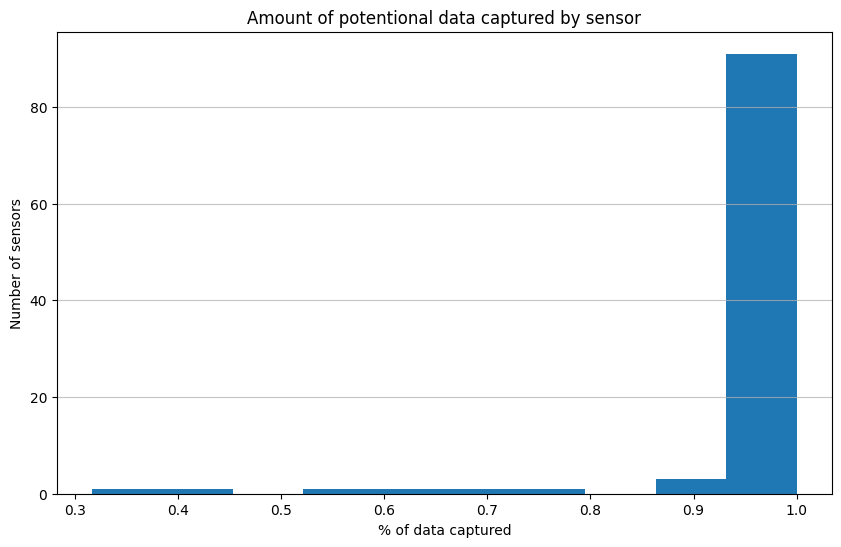

In [77]:
import matplotlib.pyplot as plt

# Create a histogram for 'Completeness %'
plt.figure(figsize=(10, 6))
plt.hist(df_grouped['completeness %'])
plt.title('Amount of potentional data captured by sensor')
plt.xlabel('% of data captured')
plt.ylabel('Number of sensors')
plt.grid(axis='y', alpha=0.75)
plt.show()

'''
Visualisation of a percentage how much of the total potential data is being captured by each sensor.
'''

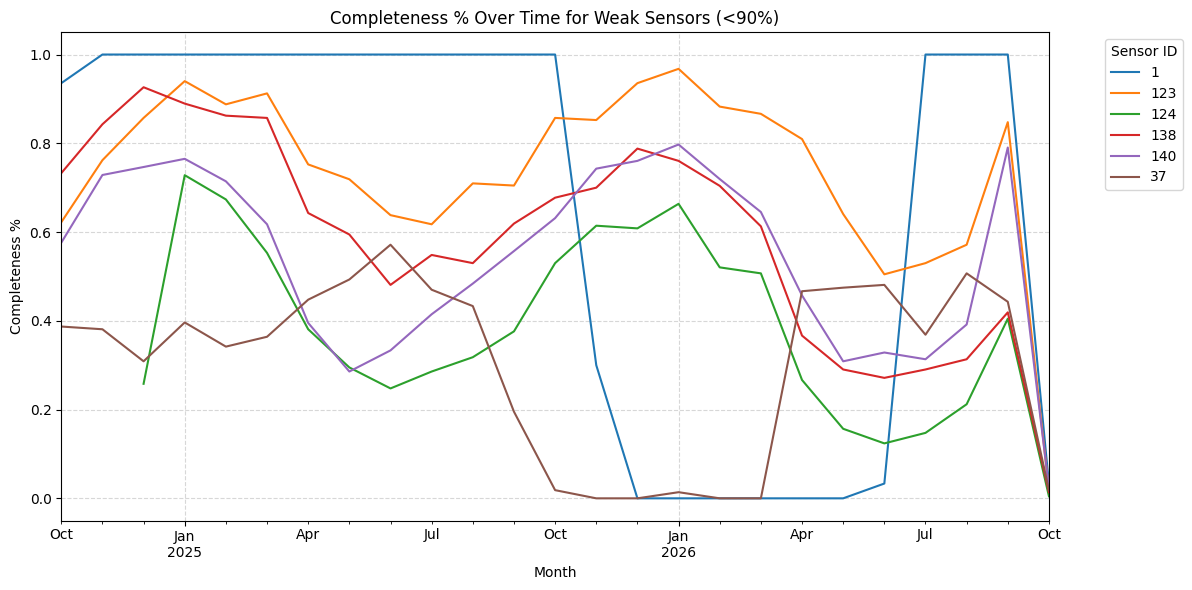

'\nThe graph shows that sensor 1 operated perfectly and than had an outage over the period of a few months.\nsensor 37 is the least realiable also with a significant outage.\nsensors 123, 124, 138, 140 have seasonal behaviour in terms of relialbity, this could be due to solar or electrical reasons.\n'

In [63]:
#Comparing weak sensors against ideal output
weak_sensors = df_grouped[df_grouped['completeness %'] < .9].sort_values('completeness %').reset_index()  #Identify all sensors that perform under 90%
df['weak_sensor'] = df['location_id'].isin(weak_sensors['location_id'])         #Create new column flagging weak sensors

df['month'] = df['sensing_date'].dt.to_period("M")                              #Set new column to indicate month of each row
df['season'] = df['sensing_date'].dt.to_period("Q")                              #Set new column to indicate month of each row

month_hour_count = df.groupby(['location_id', 'month'])['hourday'].count().unstack(fill_value=0)    #Find hours counted per sensor per month,
    #unstack changes shape of table and fills missing values where sensors failed to report including before and after activation

expected_month_hour_count = pd.DataFrame(                                       #New data frame illustrating how many hours should have been captured by sensor per month
    month_hour_count.columns.map(lambda x: x.days_in_month * 7),
    index = month_hour_count.columns)

completeness_table = month_hour_count.div(expected_month_hour_count.T.squeeze(), axis=1)            #Finding completeness %, similar to above but table shape specific
    #Due to .unstack filling in missing values, this completeness percentage takes into account missing values rather than skipping over them

start_months = df_grouped['start_day'].dt.to_period("M")                        #Series of sensor start months
finish_months = df_grouped['finish_day'].dt.to_period("M")                      #Series of sensor finish months

months_active = pd.DataFrame({m: (start_months <= m) & (m <= finish_months) for m in completeness_table.columns})
    #Dict comprehension creates a table of boolean values that are dictated by whether the month falls in a specific sensors lifespan (Start and finish date)

completeness_table = completeness_table.where(months_active)                    #Replacing values that fall outside of sensors lifespan with NaN

weak_location_ids = weak_sensors['location_id']                       # Filter completeness_table to only include weak sensors
weak_completeness = completeness_table.loc[completeness_table.index.isin(weak_location_ids)]

    # Plot weak sensors completeness over time
plt.figure(figsize=(12, 6))
weak_completeness.T.plot(ax=plt.gca())
plt.title('Completeness % Over Time for Weak Sensors (<90%)')
plt.xlabel('Month')
plt.ylabel('Completeness %')
plt.legend(title='Sensor ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

'''
The graph shows that sensor 1 operated perfectly and than had an outage over the period of a few months.
sensor 37 is the least realiable also with a significant outage.
sensors 123, 124, 138, 140 have seasonal behaviour in terms of relialbity, this could be due to solar or electrical reasons.
'''

In [64]:
months = df.sensing_date.dt.month                                               #Generate a single column series of month number in the specific order of each row in the db
df['season'] = months.map({1: "Summer", 2: "Summer", 3: "Autumn",               #For each number in the above df, assign a certain season and then add this column into df
                          4: 'Autumn', 5: 'Autumn', 6: 'Winter',
                          7: 'Winter', 8: 'Winter', 9: 'Spring',
                          10: 'Spring', 11: 'Spring', 12: 'Summer'})

df['season'] = pd.Categorical(df['season'],                                         #pandas now treats categories list as the official order. So sorting and groupby follow
                              categories=['Summer', 'Autumn', 'Winter', 'Spring'],  #Summer → Autumn → Winter → Spring instead of A–Z.
                              ordered=True)

filtered_hours = (df[df['location_id'].isin(['123', '124', '138', '140'])]          #hardcode, filter weak sensers that drop through winter
                  .groupby(['location_id', 'season', 'hourday'], observed=True)['hourday'].count() #hour group for specific grouping
                  .unstack(fill_value=0)                                            #Create table for reading, could also use visual graph?
    )

filtered_hours = filtered_hours.div(filtered_hours.max(axis=1), axis=0)         #Dived each element in table by max hours actually captured by indivdual sensor
                                                                                #to get share of possible data captured for that row. Which hours drop off compared to the others
display(filtered_hours.style.background_gradient(axis=None))
    # Gradient: close. It colours each cell on a scale compared to the other cells in its row (axis=1).
    # Use axis=0 to compare down each column.
    # axis=None to compare across the whole table


'''
Table shows that the amount of hours capture in comparison to each rows best performance.
The results detail better performance in earlier hours and a tailing performance later on.
This becomes particularly distinct during the seasons of Winter and Autumn.

Why is this analyised?
The weaker sensors need their missing values replaced in a way that won't skew the results,
less we take particular areas of the senser out of consideration for the ultimate business question.
Each sensor's average comes only from the hours it did record, calculated per hour and season before combining,
rather than as a plain mean.

MCAR MAR or MNAR: MAR: missing at random, the pattern can be explained by variables within the data, its systematic.
'''


"\nTable shows that the amount of hours capture in comparison to each rows best performance.\nThe results detail better performance in earlier hours and a tailing performance later on.\nThis becomes particularly distinct during the seasons of Winter and Autumn.\n\nWhy is this analyised?\nThe weaker sensors need their missing values replaced in a way that won't skew the results, \nless we take particular areas of the senser out of consideration for the ultimate business question.\nEach sensor's average comes only from the hours it did record, calculated per hour and season before combining, \nrather than as a plain mean.\n\nMCAR MAR or MNAR: MAR: missing at random, the pattern can be explained by variables within the data, its systematic.\n"

In [82]:
days_of_week = df.sensing_date.dt.day_name()   #Generate a single column series of day of week numbers in the specific order of each row in the db

df['days_of_week'] = pd.Categorical(days_of_week,                               #pandas now treats categories list as the official order.
                              categories=['Monday', 'Tuesday', 'Wednesday',     #So sorting and groupby follow the detailed order
                                        'Thursday', 'Friday', 'Saturday',
                                        'Sunday'],
                              ordered=True)

pedestrians_totals = df.groupby(['location_id', 'sensing_date',
                                  'season', 'days_of_week'], observed = True).agg(pedestrian_sum =('pedestriancount', 'sum'),
                                                                   hours = ('hourday', 'count')
                                                                  ).reset_index()

full_nights = pedestrians_totals[pedestrians_totals['hours'] == 7].copy()

full_nights['Q1'] = full_nights.groupby(['location_id', 'season', 'days_of_week'],
                                                                        observed = True)['pedestrian_sum'].transform(
                                                                            lambda x: x.quantile(0.25))

full_nights['Q3'] = full_nights.groupby(['location_id', 'season', 'days_of_week'],
                                                                        observed = True)['pedestrian_sum'].transform(
                                                                            lambda x: x.quantile(0.75))

full_nights['Q-upper'] = 1.5 * (full_nights['Q3'] - full_nights['Q1']) + full_nights['Q3']
full_nights['Q-lower'] =  full_nights['Q1'] - (1.5 * (full_nights['Q3'] - full_nights['Q1']))


full_nights['outlier'] = full_nights['Q-upper'] < full_nights['pedestrian_sum']


print(full_nights)

'''
Given the data set is over two years, it should be noted that the certinty of some annual events/ onmiallies occuring is limited.
A night with some hours missing gets a daily total that's simply smaller, because it summed over fewer hours. The lower fence will catch those, mixed in with genuinely quiet nights.
A night with all hours missing has no row at all, so it never shows up.

Q1 to Q3 is the middle 50% of nights for group sensor, season, day (the "interquartile range"),
not the median range. The fences are the limits of normal. Q3 is just where the busier half starts.

'''

      location_id sensing_date  season days_of_week  pedestrian_sum  hours  \
0               1   2024-10-03  Spring     Thursday           14441      7   
1               1   2024-10-04  Spring       Friday           14470      7   
2               1   2024-10-05  Spring     Saturday            8396      7   
3               1   2024-10-06  Spring       Sunday            8492      7   
4               1   2024-10-07  Spring       Monday            7304      7   
...           ...          ...     ...          ...             ...    ...   
70045           9   2026-09-27  Spring       Sunday             728      7   
70046           9   2026-09-28  Spring       Monday            4633      7   
70047           9   2026-09-29  Spring      Tuesday            6392      7   
70048           9   2026-09-30  Spring    Wednesday            6092      7   
70049           9   2026-10-01  Spring     Thursday            3720      7   

             Q1        Q3    Q-upper   Q-lower  outlier  
0    

'\nGiven the data set is over two years, it should be noted that the certinty of some annual events/ onmiallies occuring is limited.\nA night with some hours missing gets a daily total that\'s simply smaller, because it summed over fewer hours. The lower fence will catch those, mixed in with genuinely quiet nights.\nA night with all hours missing has no row at all, so it never shows up.\n\nQ1 to Q3 is the middle 50% of nights for group sensor, season, day (the "interquartile range"), \nnot the median range. The fences are the limits of normal. Q3 is just where the busier half starts.\n\n'